<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# Atmosphere Analysis 3 — Differential Flux Generation — Honda Tables

**Description:** Generates and saves the full height-differential atmospheric neutrino source flux
$\Phi(E,h;\alpha)$ for all Honda flavours and the standard 20-bin Honda $\cos Z = \cos\alpha$ grid, using
CPU parallelism via joblib. Saved files are loaded back at the end and visualised.

**Physics:** $\Phi(E,h;\alpha) = \Phi(E;\alpha) \times f(h|E,\alpha)$ at the Honda surface angle; saved files also store detector $\theta$.

**Source:** Honda/HKKM tables  ·  `external.honda.generator`



| # | Section |
|---|---------|
| [0](#0.-Theory-Summary) | **Theory Summary** |
| [1](#1.-Setup) | **Setup**: imports and configuration |
| [2](#2.-Generation-Parameters) | **Generation Parameters**: 2.1 table selection, 2.2 particles, 2.3 angle grid, 2.4 energy \& height grids, 2.5 parallel \& save config |
| [3](#3.-Output-Run-Directory) | **Output Run Directory**: auto-increment `runXXXX` |
| [4](#4.-Generate-and-Save) | **Generate and Save**: run the Honda generator |
| [5](#5.-Verify-Output) | **Verify Output**: list saved files |
| [6](#6.-Load-and-Inspect) | **Load and Inspect**: 6.1 load dataset, 6.2 summary, 6.3 energy spectra $\Phi(E;\alpha)$, 6.4 height PDF $f(h|E,\alpha)$, 6.5 differential flux $\Phi(E,h;\alpha)$ heatmap |

## 0. Theory Summary

This notebook generates data; the full theoretical derivation is in
**Atmosphere Analysis 2** (`atmosphere2_Differential_Flux_Honda_Generation`).
The key quantities are recalled here for reference.

| Symbol | Definition | Source |
|--------|-----------|--------|
| $\Phi(E;\alpha)$ | Height-integrated flux at the detector | Honda flux table |
| $F(h_p\|E,\alpha) = p$ | CDF quantiles of the production-height distribution | Honda height table |
| $f(h\|E,\alpha)$ | Production-height PDF reconstructed from quantiles as $\mathrm{d}F/\mathrm{d}h$ | tpeanuts |
| $\Phi(E,h;\alpha)$ | Height-differential source flux $= \Phi(E;\alpha)\times f(h\|E,\alpha)$ | tpeanuts |

The saved files contain all three quantities as torch tensors indexed by
$(n_E, n_h)$ together with the energy and height grids and provenance metadata.

**Reference:** M. Honda et al., Phys. Rev. D **92**, 023004 (2015).
**Web:** [http://www.icrr.u-tokyo.ac.jp/~mhonda/](http://www.icrr.u-tokyo.ac.jp/~mhonda/)

## 1. Setup

In [1]:
from __future__ import annotations

import os
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show
import tpeanuts.config.default as default
from tpeanuts.external.honda import (
    HondaTableSelection,
    generate_flux_for_particles_angle_grid,
    find_honda_data_dir,
    honda_cosz_centers,
)
from tpeanuts.medium.atmosphere.io import OutputConfig, load_directory
from tpeanuts.util.parallel import ParallelConfig

In [2]:
config     = load_notebook_config()
OUTPUT_DIR = config.output_dir('analysis', 'atmosphere','honda_generation')
BASE_FLUX_DIR = config.output_root / 'data' / 'flux' / 'differential' / 'Honda'
HONDA_DIR = default.honda_dataset

SHOW_PLOTS = config.show_plots
print(f"Honda Tables directory : {HONDA_DIR}")
print(f'Data output root       : {config.output_root}')
print(f"Flux Output directory  : {BASE_FLUX_DIR}")
print(f'Analysis output        : {OUTPUT_DIR}')


Honda Tables directory : G:\Mi unidad\04.Datasets\Honda
Data output root       : v:\output
Flux Output directory  : v:\output\data\flux\differential\Honda
Analysis output        : v:\output\analysis\atmosphere\honda_generation


## 2. Generation Parameters

All parameters that control the generation are defined here as module-level
constants so they can be inspected and changed without touching the run cell.

### 2.1 Honda Table Selection

Select the Honda/HKKM table variant: site, season, solar activity, mountain flag,
and angular binning. Defaults match the Frejus all-year azimuth-averaged solar-minimum
flux, which is the standard configuration for JUNO and Frejus-based analyses.

In [3]:
HONDA_SELECTION = HondaTableSelection(
    site_code            = "frj",
    season_code          = "ally",
    solar                = "solmin",
    mountain             = False,
    angular_mode         = "azimuth-averaged",
    azimuth_averaged_height = True,
)
print(f'Selection: {HONDA_SELECTION}')

Selection: HondaTableSelection(site_code='frj', season_code='ally', solar='solmin', mountain=False, angular_mode='azimuth-averaged', azimuth_averaged_height=True)


### 2.2 Particle List

The generator produces one file per (particle, $\alpha$) pair. Honda publishes
production-height tables for $\nu_\mu$, $\bar\nu_\mu$, $\nu_e$, $\bar\nu_e$.
Tau neutrinos fall back to the $\nu_\mu$ height table (same hadronic shower origin).

In [4]:
PARTICLES = {
    "nue":      "nue",
    "antinue":  "antinue",
    "numu":     "numu",
    "antinumu": "antinumu",
    "nutau":    "nutau",
    "antinutau":"antinutau",
}
print(f'Particles ({len(PARTICLES)}): {list(PARTICLES)}')

Particles (6): ['nue', 'antinue', 'numu', 'antinumu', 'nutau', 'antinutau']


### 2.3 Angle Grid

Use the full standard 20-bin Honda $\cos Z = \cos\alpha$ grid returned by
`honda_cosz_centers()`. This covers $\cos\alpha \in [-0.95, 0.95]$ with
step 0.10 (20 zenith angles from $\alpha\approx18°$ down to $\alpha\approx162°$).
Only downward-going directions ($\cos\alpha > 0$, $\alpha < 90°$) are used for
propagation; the full grid is generated for completeness.

In [5]:
cosz_centers  = honda_cosz_centers()           # (20,) array, 0.95 .. -0.95
# Keep only downward-going Honda bins and convert cosZ = cos(alpha_surface) to alpha
cosz_down     = cosz_centers[cosz_centers > 0] # (10,) from 0.95 to 0.05
ALPHA_GRID_DEG = torch.rad2deg(
    torch.acos(torch.as_tensor(cosz_down, dtype=torch.float64))
).sort().values

print(f'Honda cosZ centres (down): {cosz_down}')
print(f'Surface alpha grid (deg) : {ALPHA_GRID_DEG.numpy().round(2)}')
print(f'n_alpha                  : {len(ALPHA_GRID_DEG)}')

Honda cosZ centres (down): [0.95 0.85 0.75 0.65 0.55 0.45 0.35 0.25 0.15 0.05]
Surface alpha grid (deg) : [18.19 31.79 41.41 49.46 56.63 63.26 69.51 75.52 81.37 87.13]
n_alpha                  : 10


### 2.4 Energy and Height Grids

- **Energy grid:** `None` uses the Honda native log-spaced grid (~50 points, 0.1–10 000 GeV).
  A custom grid can be supplied as a 1D tensor.
- **Height grid:** 501 points from 0 to 120 km (0.24 km resolution).

In [6]:
ENERGY_GRID_GEV = None          # None -> Honda native grid
H_GRID_KM = torch.linspace(0.0, 120.0, 501, dtype=torch.float64)
print(f'Energy grid  : {"Honda native" if ENERGY_GRID_GEV is None else len(ENERGY_GRID_GEV)} points')
print(f'Height grid  : {len(H_GRID_KM)} points, {float(H_GRID_KM[0]):.1f} - {float(H_GRID_KM[-1]):.1f} km')

Energy grid  : Honda native points
Height grid  : 501 points, 0.0 - 120.0 km


### 2.5 Parallel and Save Configuration

Joblib `loky` backend spawns separate worker processes — one per (particle, $\alpha$) job.
Set `PARALLEL = False` to fall back to a sequential loop (useful for debugging).
The output dtype is `float32` to halve disk usage; computations run in `float64`.

In [7]:
PARALLEL         = True
N_JOBS           = -1          # -1 -> all available CPUs
PARALLEL_BACKEND = 'loky'

SAVE_DTYPE  = torch.float32    # on-disk dtype (halves storage vs float64)
COMPUTE_DTYPE = torch.float64  # internal computation dtype
OVERWRITE   = False            # skip already-generated files
SKIP_EXISTING = True

parallel_config = ParallelConfig(
    parallel = PARALLEL,
    n_jobs   = N_JOBS,
    backend  = PARALLEL_BACKEND,
)
parallel_config.validate()
print(f'Parallel : {PARALLEL}  n_jobs={N_JOBS}  backend={PARALLEL_BACKEND!r}')
print(f'Save dtype: {SAVE_DTYPE}  Compute dtype: {COMPUTE_DTYPE}')

Parallel : True  n_jobs=-1  backend='loky'
Save dtype: torch.float32  Compute dtype: torch.float64


## 3. Output Run Directory

Each generation run is stored in its own `runXXXX` subdirectory under
`{output_root}/data/flux/differential/Honda/`. The helper `next_run_dir()`
finds the lowest available index so re-running the notebook creates a new
directory instead of overwriting previous results.

In [8]:
def next_run_dir(base: Path) -> Path:
    """Return the next available runXXXX directory (does not create it)."""
    base.mkdir(parents=True, exist_ok=True)
    for i in range(1, 10_000):
        candidate = base / f'run{i:04d}'
        if not candidate.exists():
            return candidate
    raise RuntimeError('Exhausted run directories (max 9999)')

RUN_DIR       = next_run_dir(BASE_FLUX_DIR)
RUN_DIR.mkdir(parents=True, exist_ok=True)

output_config = OutputConfig(
    output_dir       = RUN_DIR,
    filename         = 'diff_flux.pt',
    dtype            = SAVE_DTYPE,
    compressed       = True,
    overwrite        = OVERWRITE,
    save_intermediate= False,
)
output_config.validate()

n_jobs_total = len(PARTICLES) * len(ALPHA_GRID_DEG)
print(f'Run directory   : {RUN_DIR}')
print(f'Honda data dir  : {find_honda_data_dir(path=HONDA_DIR)}')
print(f'Files to write  : {n_jobs_total} ({len(PARTICLES)} particles x {len(ALPHA_GRID_DEG)} angles)')

Run directory   : v:\output\data\flux\differential\Honda\run0001
Honda data dir  : G:\Mi unidad\04.Datasets\Honda
Files to write  : 60 (6 particles x 10 angles)


## 4. Generate and Save

`generate_flux_for_particles_angle_grid` runs all (particle, $\alpha$) jobs,
sharing the loaded Honda tables across workers to avoid redundant file I/O.
Each job writes one `.pt` file to `RUN_DIR`.

In [9]:
print('Starting generation...')
print(f'  Selection : {HONDA_SELECTION}')
print(f'  Particles : {list(PARTICLES)}')
print(f'  Alpha grid: {ALPHA_GRID_DEG.numpy().round(2)} deg')
print(f'  Parallel  : {PARALLEL}  n_jobs={N_JOBS}')
print(f'  Output    : {RUN_DIR}')
print()

gen_results = generate_flux_for_particles_angle_grid(
    honda_data_dir  = HONDA_DIR,
    particles       = PARTICLES,
    alpha_grid_deg  = ALPHA_GRID_DEG,
    selection       = HONDA_SELECTION,
    energy_grid_GeV = ENERGY_GRID_GEV,
    h_grid_km       = H_GRID_KM,
    output_config   = output_config,
    parallel_config = parallel_config,
    save            = True,
    skip_existing   = SKIP_EXISTING,
    device          = 'cpu',
    dtype           = COMPUTE_DTYPE,
    debug           = True,
)

n_saved = sum(len(v['results']) for v in gen_results.values())
print(f'\nDone. {n_saved} files written to {RUN_DIR}')

Starting generation...
  Selection : HondaTableSelection(site_code='frj', season_code='ally', solar='solmin', mountain=False, angular_mode='azimuth-averaged', azimuth_averaged_height=True)
  Particles : ['nue', 'antinue', 'numu', 'antinumu', 'nutau', 'antinutau']
  Alpha grid: [18.19 31.79 41.41 49.46 56.63 63.26 69.51 75.52 81.37 87.13] deg
  Parallel  : True  n_jobs=-1
  Output    : v:\output\data\flux\differential\Honda\run0001

Generating 60 Honda flux jobs (6 particles x 10 angles). parallel=True


Honda flux generation: 100%|███████████████████████████████████████████████████████████| 60/60 [00:09<00:00,  6.45it/s]



Done. 60 files written to v:\output\data\flux\differential\Honda\run0001


## 5. Verify Output

List the generated `.pt` files grouped by particle.

In [10]:
from collections import defaultdict
import re

pt_files = sorted(RUN_DIR.glob('*.pt'))
print(f'{len(pt_files)} files in {RUN_DIR}\n')

by_particle = defaultdict(list)
for f in pt_files:
    # extract particle name from filename
    m = re.search(r'diff_flux_([a-z]+)_', f.name)
    key = m.group(1) if m else 'unknown'
    by_particle[key].append(f.name)

for particle, files in sorted(by_particle.items()):
    print(f'  {particle:12s}: {len(files)} files')
    for name in files[:3]:
        print(f'    {name}')
    if len(files) > 3:
        print(f'    ... (+{len(files)-3} more)')

60 files in v:\output\data\flux\differential\Honda\run0001

  antinue     : 10 files
    diff_flux_antinue_alpha_18p195deg.pt
    diff_flux_antinue_alpha_31p788deg.pt
    diff_flux_antinue_alpha_41p410deg.pt
    ... (+7 more)
  antinumu    : 10 files
    diff_flux_antinumu_alpha_18p195deg.pt
    diff_flux_antinumu_alpha_31p788deg.pt
    diff_flux_antinumu_alpha_41p410deg.pt
    ... (+7 more)
  antinutau   : 10 files
    diff_flux_antinutau_alpha_18p195deg.pt
    diff_flux_antinutau_alpha_31p788deg.pt
    diff_flux_antinutau_alpha_41p410deg.pt
    ... (+7 more)
  nue         : 10 files
    diff_flux_nue_alpha_18p195deg.pt
    diff_flux_nue_alpha_31p788deg.pt
    diff_flux_nue_alpha_41p410deg.pt
    ... (+7 more)
  numu        : 10 files
    diff_flux_numu_alpha_18p195deg.pt
    diff_flux_numu_alpha_31p788deg.pt
    diff_flux_numu_alpha_41p410deg.pt
    ... (+7 more)
  nutau       : 10 files
    diff_flux_nutau_alpha_18p195deg.pt
    diff_flux_nutau_alpha_31p788deg.pt
    diff_flux_nutau

## 6. Load and Inspect

`load_directory` reads all `.pt` files in `RUN_DIR`, groups them by particle,
checks grid consistency, sorts by $\alpha$, and stacks the tensors into
$(n_\alpha, n_E, n_h)$ batched arrays.

### 6.1 Load Dataset

In [11]:
dataset = load_directory(
    str(RUN_DIR),
    map_location = 'cpu',
    dtype        = torch.float64,
    group_by     = 'particle',
    verbose      = True,
)

Loaded antinue      | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded antinumu     | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded antinutau    | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded nue          | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded numu         | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded nutau        | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)


### 6.2 Dataset Summary

Print shapes of the stacked tensors and the energy/height grids.

In [12]:
# Reference grids (same for all particles)
ref = next(iter(dataset.values()))
E_grid = ref['E_grid_GeV'].numpy()
h_grid = ref['h_grid_km'].numpy()
theta_grid = ref['theta_grid_deg'].numpy()
alpha_grid = ref.get('alpha_grid_deg', ref['theta_grid_deg']).numpy()

print(f'Energy grid : {len(E_grid)} points, {E_grid[0]:.3f} - {E_grid[-1]:.1f} GeV')
print(f'Height grid : {len(h_grid)} points, {h_grid[0]:.1f} - {h_grid[-1]:.1f} km')
print(f'Theta grid  : {len(theta_grid)} detector-angle points, {theta_grid[0]:.2f} - {theta_grid[-1]:.2f} deg')
print(f'Alpha grid  : {len(alpha_grid)} surface-angle points, {alpha_grid[0]:.2f} - {alpha_grid[-1]:.2f} deg')
print()
print(f'{"Particle":12s}  {"phi(E,theta,h)":18s}  {"phi(E,theta)":14s}  {"f(theta,E,h)":14s}')
print('-' * 64)
for p, d in sorted(dataset.items()):
    print(f'{p:12s}  {str(tuple(d["phi_E_theta_h"].shape)):18s}  {str(tuple(d["phi_E_theta"].shape)):14s}  {str(tuple(d["f_theta_E_h"].shape)):14s}')

Energy grid : 101 points, 0.100 - 10000.0 GeV
Height grid : 501 points, 0.0 - 120.0 km
Theta grid  : 10 detector-angle points, 18.19 - 87.13 deg
Alpha grid  : 10 surface-angle points, 18.19 - 87.13 deg

Particle      phi(E,theta,h)      phi(E,theta)    f(theta,E,h)  
----------------------------------------------------------------
antinue       (10, 101, 501)      (10, 101)       (10, 101, 501)
antinumu      (10, 101, 501)      (10, 101)       (10, 101, 501)
antinutau     (10, 101, 501)      (10, 101)       (10, 101, 501)
nue           (10, 101, 501)      (10, 101)       (10, 101, 501)
numu          (10, 101, 501)      (10, 101)       (10, 101, 501)
nutau         (10, 101, 501)      (10, 101)       (10, 101, 501)


### 6.3 Energy Spectra $\Phi(E;\alpha)$

The height-integrated flux for $\nu_\mu$ as a function of energy for each
generated surface/Honda zenith angle.

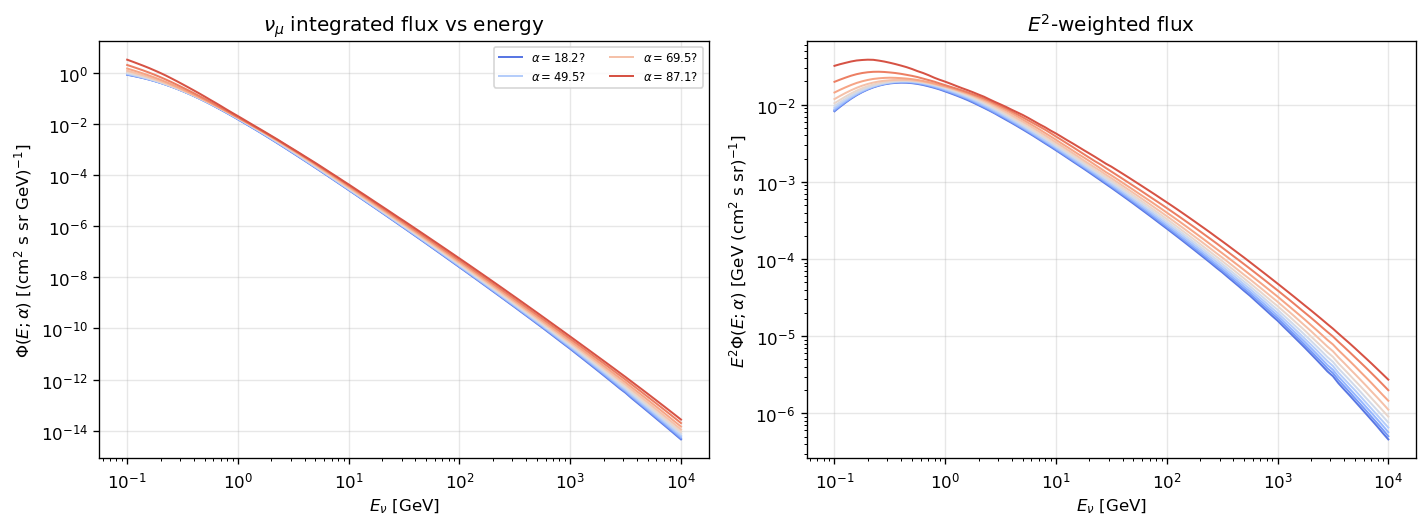

v:\output\analysis\atmosphere\honda_generation\atm3_fig63_phi_E_theta.png


In [13]:
PARTICLE_SHOW = 'numu'
d = dataset[PARTICLE_SHOW]
phi_E_alpha = d['phi_E_theta'].numpy()   # saved key, indexed as (n_alpha, n_E)
theta_arr   = d['theta_grid_deg'].numpy()
alpha_arr   = d.get('alpha_grid_deg', d['theta_grid_deg']).numpy()
E_arr       = d['E_grid_GeV'].numpy()

colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, len(alpha_arr)))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for i, (theta, alpha, col) in enumerate(zip(theta_arr, alpha_arr, colors)):
    axes[0].loglog(E_arr, phi_E_alpha[i], color=col, lw=1.2,
                   label=rf'$\alpha={alpha:.1f}?$' if i % 3 == 0 else None)
    axes[1].loglog(E_arr, E_arr**2 * phi_E_alpha[i], color=col, lw=1.2)

axes[0].set_xlabel('$E_{\\nu}$ [GeV]')
axes[0].set_ylabel(r'$\Phi(E;\alpha)$ [(cm$^2$ s sr GeV)$^{-1}$]')
axes[0].set_title(rf'$\nu_\mu$ integrated flux vs energy')
axes[0].legend(fontsize=7, ncol=2)

axes[1].set_xlabel('$E_{\\nu}$ [GeV]')
axes[1].set_ylabel(r'$E^2\Phi(E;\alpha)$ [GeV (cm$^2$ s sr)$^{-1}$]')
axes[1].set_title(r'$E^2$-weighted flux')

fig.tight_layout()
save_and_show('atm3_fig63_phi_E_theta.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.4 Production-Height PDF $f(h|E,\theta)$

The height density at a fixed reference surface angle $\alpha_0$ for several energies.

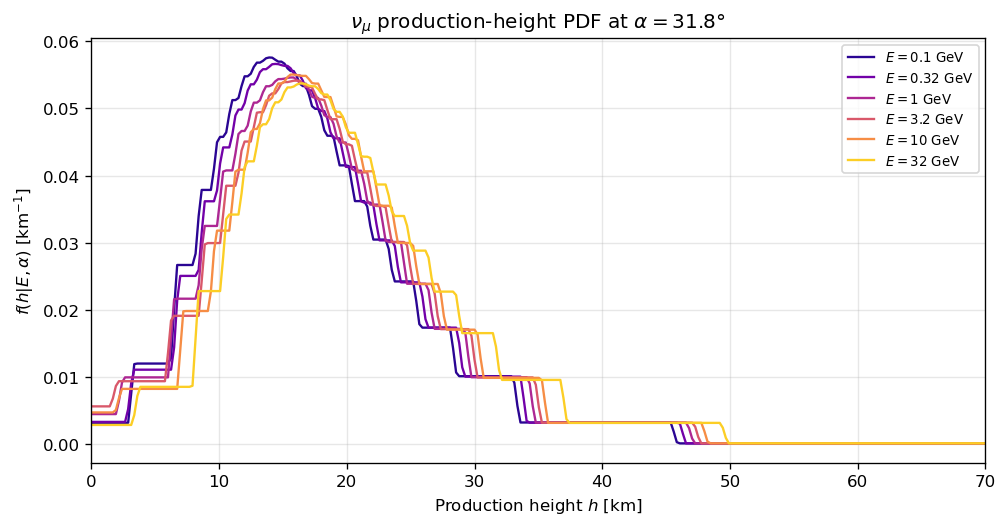

v:\output\analysis\atmosphere\honda_generation\atm3_fig64_fEh.png


In [14]:
ALPHA0 = 30.0    # reference surface/Honda zenith angle in degrees
i_alpha = int(np.argmin(np.abs(alpha_arr - ALPHA0)))
theta_actual = float(theta_arr[i_alpha])
alpha_actual = float(alpha_arr[i_alpha])

f_alpha_E_h = dataset[PARTICLE_SHOW]['f_theta_E_h'].numpy()  # saved key, indexed as (n_alpha, n_E, n_h)
f_at_alpha  = f_alpha_E_h[i_alpha]                           # (n_E, n_h)

E_show = [0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
colors_e = plt.cm.plasma(np.linspace(0.05, 0.90, len(E_show)))

fig, ax = plt.subplots(figsize=(8.5, 4.5))
for E_ref, col in zip(E_show, colors_e):
    ie = int(np.argmin(np.abs(E_arr - E_ref)))
    ax.plot(h_grid, f_at_alpha[ie], color=col, lw=1.4,
            label=rf'$E={E_arr[ie]:.2g}$ GeV')
ax.set_xlabel('Production height $h$ [km]')
ax.set_ylabel(r'$f(h|E,\alpha)$ [km$^{-1}$]')
ax.set_title(rf'$\nu_\mu$ production-height PDF at $\alpha={alpha_actual:.1f}°$')
ax.legend(fontsize=8)
ax.set_xlim(0, 70)
fig.tight_layout()
save_and_show('atm3_fig64_fEh.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

### 6.5 Height-Differential Flux $\Phi(E,h;\alpha)$

2-D heatmap of $\log_{10}\Phi(E,h;\alpha)$ at the reference angle.
This is the quantity passed to the atmospheric neutrino propagator as the
upper boundary condition.

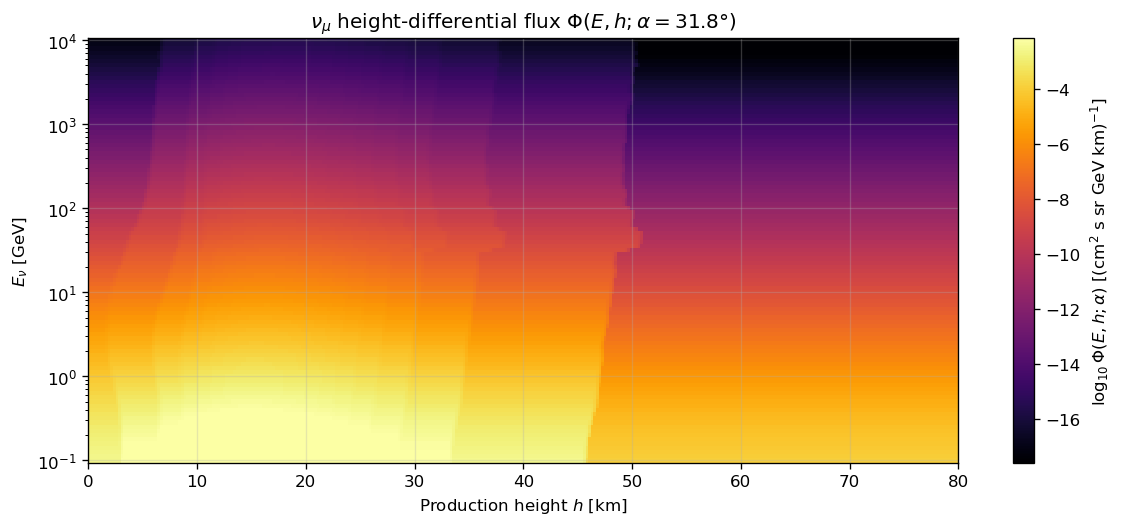

v:\output\analysis\atmosphere\honda_generation\atm3_fig65_phi_Eh_heatmap.png


In [15]:
phi_E_alpha_h = dataset[PARTICLE_SHOW]['phi_E_theta_h'].numpy()  # saved key, indexed as (n_alpha, n_E, n_h)
phi_at_alpha  = phi_E_alpha_h[i_alpha]                            # (n_E, n_h)

with np.errstate(divide='ignore'):
    log_phi = np.where(phi_at_alpha > 0, np.log10(phi_at_alpha), np.nan)

fig, ax = plt.subplots(figsize=(10, 4.5))
im = ax.pcolormesh(
    h_grid, E_arr, log_phi,
    cmap='inferno', shading='auto',
    vmin=np.nanpercentile(log_phi, 2),
    vmax=np.nanpercentile(log_phi, 98),
)
cb = fig.colorbar(im, ax=ax)
cb.set_label(r'$\log_{10}\Phi(E,h;\alpha)$ [(cm$^2$ s sr GeV km)$^{-1}$]')
ax.set_yscale('log')
ax.set_xlabel('Production height $h$ [km]')
ax.set_ylabel('$E_{\\nu}$ [GeV]')
ax.set_title(rf'$\nu_\mu$ height-differential flux $\Phi(E,h;\alpha={alpha_actual:.1f}°)$')
ax.set_xlim(0, 80)
fig.tight_layout()
save_and_show('atm3_fig65_phi_Eh_heatmap.png', fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)